# W2 D27 — Open Practice: News Popularity
**Topics:** Online News Popularity (UCI/Kaggle) | Regression then classification, feature selection, pipeline

**Q1** EDA — shares distribution & channel breakdown
**Q2** Predict shares (regression)
**Q3** Binary classification (viral vs not)
**Q4** Feature selection with SelectKBest
**Q5** Business framing for HealthLine editorial team


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import mean_squared_error, roc_auc_score, r2_score
import warnings; warnings.filterwarnings('ignore')
np.random.seed(420)
print('Libraries loaded')

Libraries loaded


In [3]:
# Try Kaggle, fall back to synthetic HealthLine content metrics
try:
    import subprocess
    subprocess.run(['kaggle','datasets','download','-d','fghrsh/online-news-popularity-dataset','--unzip','-p','/tmp/news'], capture_output=True)
    df = pd.read_csv('/tmp/news/OnlineNewsPopularity.csv')
    df.columns = df.columns.str.strip()
    print(f'News popularity dataset: {df.shape}')
except:
    print('Generating synthetic HealthLine content metrics')
    n = 3000
    np.random.seed(420)
    channels = np.random.choice(['health','nutrition','mental_health','fitness','medical'], n, p=[0.3,0.2,0.2,0.2,0.1])
    n_words = np.random.randint(200, 2000, n)
    n_links = np.random.randint(0, 30, n)
    n_images = np.random.randint(0, 10, n)
    sentiment = np.random.uniform(-1, 1, n)
    day_of_week = np.random.randint(1, 8, n)
    is_weekend = (day_of_week >= 6).astype(int)
    logshares = (np.log(500) + 0.3*(channels=='health').astype(int)*1.5
                 + 0.001*n_words + 0.02*n_images + 0.3*is_weekend
                 + np.random.normal(0, 1.2, n))
    shares = np.exp(logshares).astype(int).clip(1)
    df = pd.DataFrame({'num_words_content':n_words,'num_hrefs':n_links,'num_imgs':n_images,
                       'global_sentiment_polarity':sentiment,'is_weekend':is_weekend,
                       'data_channel':channels,'shares':shares})
    print(f'Synthetic dataset: {df.shape}, median shares={np.median(shares):.0f}')

Generating synthetic HealthLine content metrics
Synthetic dataset: (3000, 7), median shares=2068


In [5]:
display(df.describe())

,num_words_content,num_hrefs,num_imgs,global_sentiment_polarity,is_weekend,shares
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1094.104333,14.657000,4.437000,-0.004346,0.273000,4662.556333
std,511.936449,8.568226,2.856353,0.571838,0.445575,8378.153523
min,200.000000,0.000000,0.000000,-0.999649,0.000000,11.000000
25%,661.000000,8.000000,2.000000,-0.493635,0.000000,832.000000
50%,1097.500000,15.000000,4.000000,-0.008767,0.000000,2068.500000
75%,1530.000000,22.000000,7.000000,0.499921,1.000000,5205.000000
max,1999.000000,29.000000,9.000000,0.999436,1.000000,104612.000000


## Q1 — EDA: Shares Distribution & Channel Breakdown

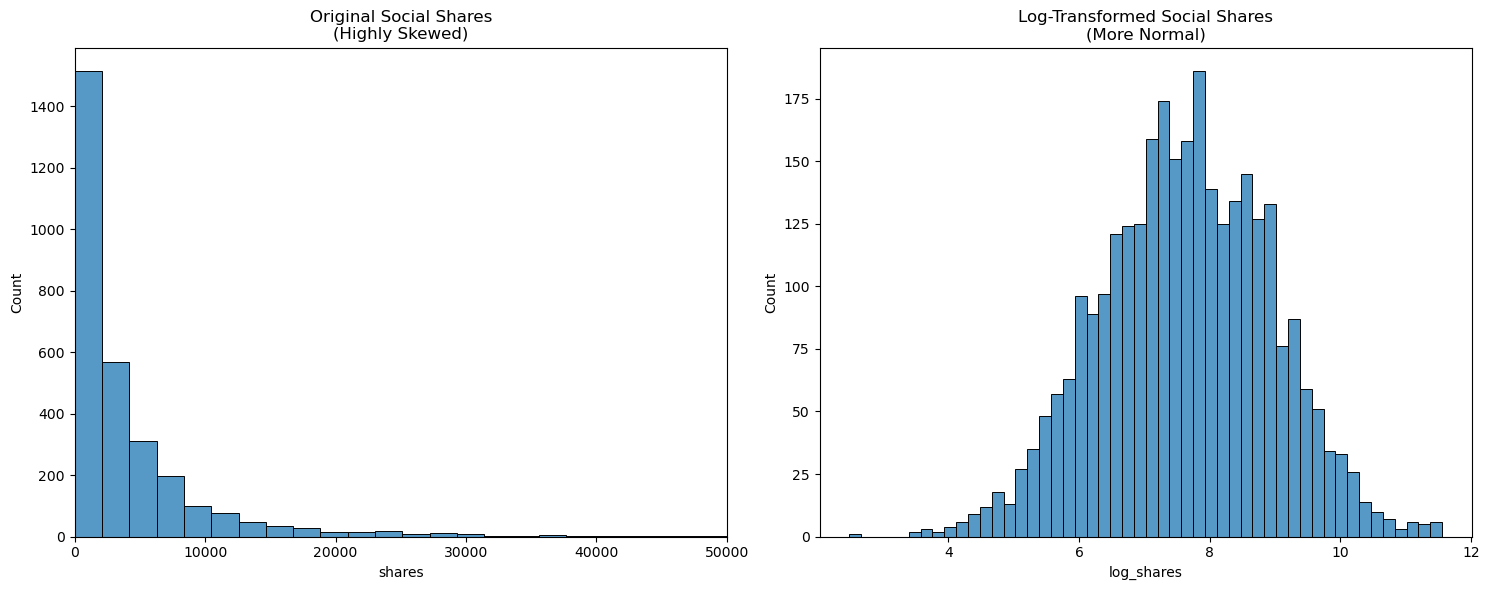

In [22]:
df['log_shares'] = np.log1p(df['shares'])

plt.figure(figsize=(15,6))

# plotting original
plt.subplot(1,2,1)
sns.histplot(df['shares'], bins=50)
plt.xlim(0, 50000)
plt.title('Original Social Shares\n(Highly Skewed)')

# plotting transformed
plt.subplot(1,2,2)
sns.histplot(df['log_shares'], bins=50)
plt.title('Log-Transformed Social Shares\n(More Normal)')

plt.tight_layout()
plt.show()

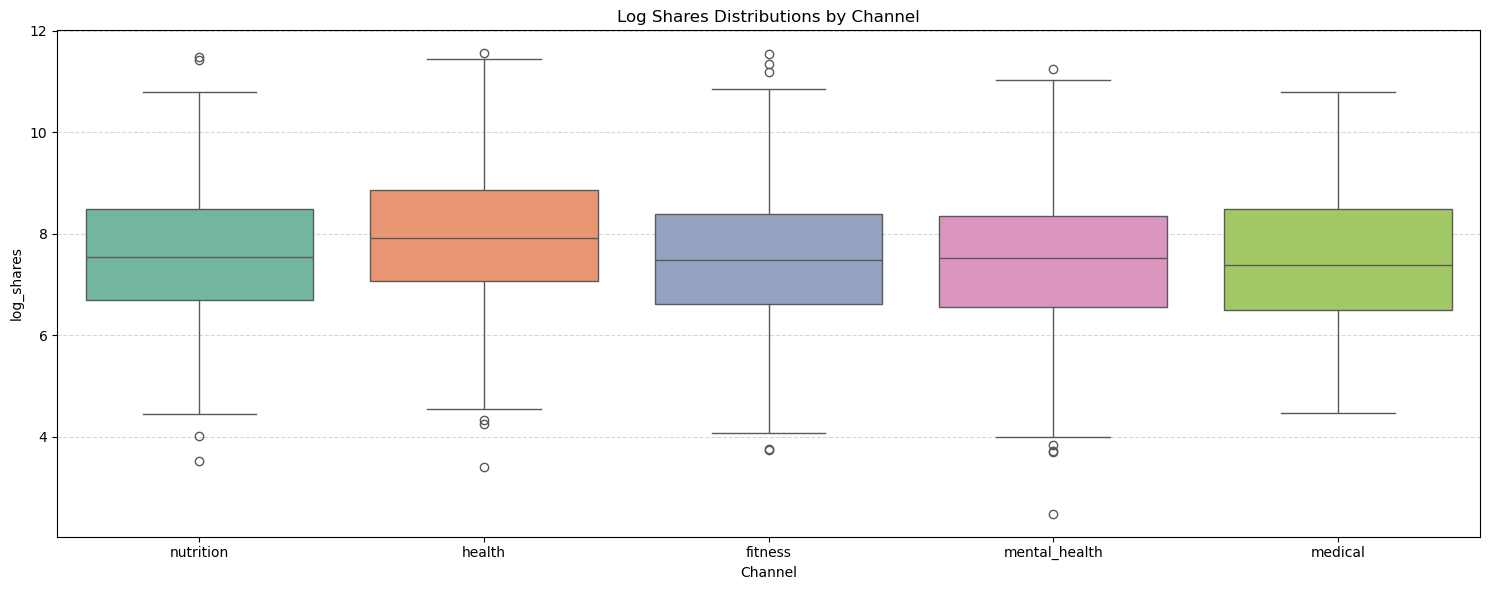

In [7]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df, x='data_channel', y='log_shares', palette='Set2')
plt.title('Log Shares Distributions by Channel')
plt.xlabel('Channel')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [8]:
# Group by channel and calculate descriptive statistics
channel_summary = df.groupby('data_channel')['shares'].agg(
    count='count',
    median_shares='median',
    mean_shares='mean',
    std_shares='std'
).reset_index()

# Sort by median performance
channel_summary = channel_summary.sort_values(by='median_shares', ascending=False)
display(channel_summary)


,data_channel,count,median_shares,mean_shares,std_shares
1,health,906,2754.0,6177.738411,10303.864269
4,nutrition,595,1869.0,4338.416807,8059.150939
3,mental_health,614,1856.0,3680.444625,6234.045135
0,fitness,601,1777.0,4051.682196,8053.128617
2,medical,284,1615.0,3924.035211,5943.666793


## Q2 — Predict Shares (Regression)

CV R² (log scale): 0.1092 ± 0.0330

Test RMSE (log scale):    1.2480
Test RMSE (shares scale): 7,760 shares
Test R² (log scale):      0.1117


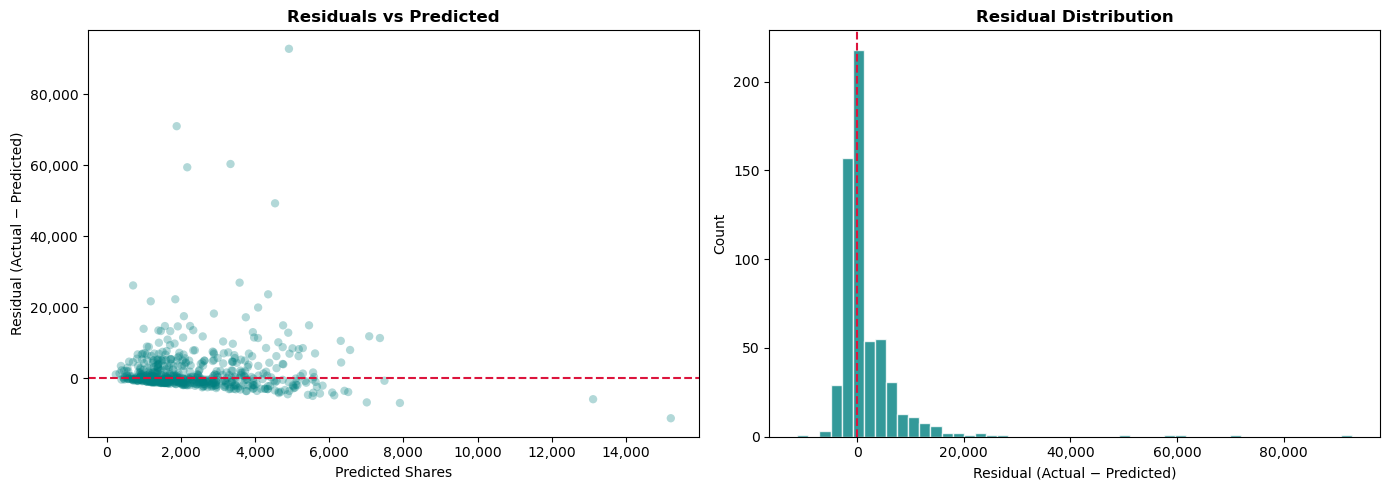

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# 1. Features and log-transformed target
X = df.drop(columns=['shares', 'log_shares'], errors='ignore')
y = np.log1p(df['shares'])

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=420
)

# 3. Preprocessor
numeric_features    = ['num_words_content', 'num_hrefs', 'num_imgs', 'global_sentiment_polarity']
categorical_features = ['data_channel']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

# 4. Pipeline — HistGBR handles noise better than RF on social sharing data
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=200,
        max_depth=5,
        random_state=420
    ))
])

# 5. Cross-validate before final fit
cv_r2 = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='r2')
print(f"CV R² (log scale): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

# 6. Fit and evaluate
model_pipeline.fit(X_train, y_train)

y_pred_log  = model_pipeline.predict(X_test)
y_pred_orig = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

rmse_log  = root_mean_squared_error(y_test, y_pred_log)
rmse_orig = root_mean_squared_error(y_test_orig, y_pred_orig)
r2_log    = r2_score(y_test, y_pred_log)

print(f"\nTest RMSE (log scale):    {rmse_log:.4f}")
print(f"Test RMSE (shares scale): {rmse_orig:,.0f} shares")
print(f"Test R² (log scale):      {r2_log:.4f}")

# 7. Residual plot
residuals = y_test_orig - y_pred_orig

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_orig, residuals, alpha=0.3, color='teal', edgecolors='none')
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Shares')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Residual distribution
axes[1].hist(residuals, bins=50, color='teal', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

## Q3 — Binary Classification: Viral vs Not

Viral threshold (75th pct, train only): 5,237 shares
Train viral rate: 25.00%
Test viral rate:  24.33%

CV AUC: 0.6569 ± 0.0106

AUPRC:                    0.3147
ROC-AUC:                  0.5824
Optimal threshold:        0.3232
Precision at threshold:   0.2876
Recall at threshold:      0.6027


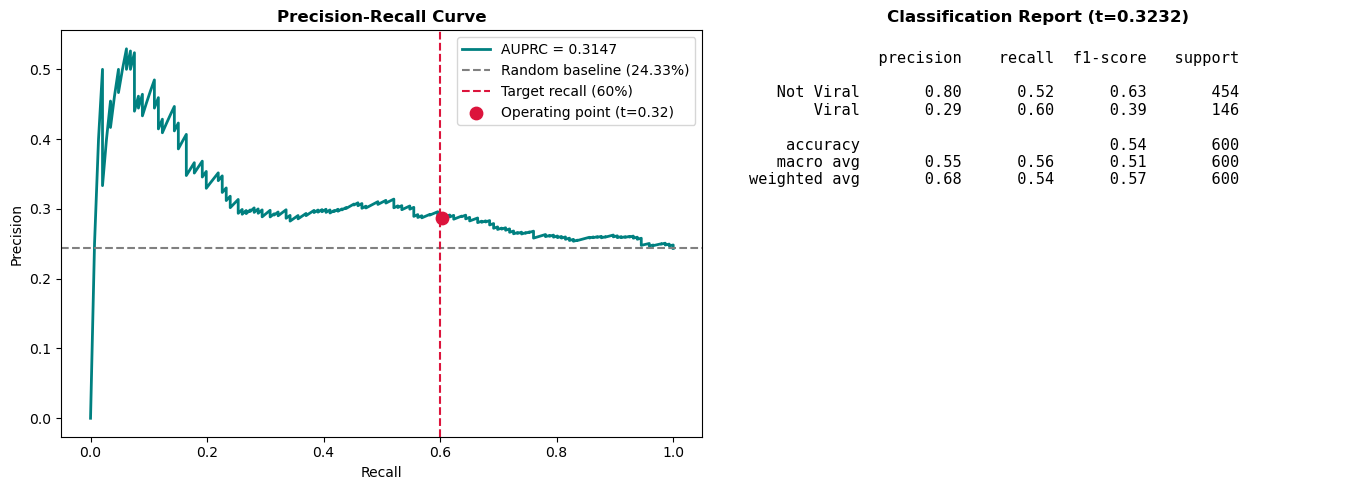


*** Q5 Reference: 60.27% viral recall at threshold 0.3232


In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from imblearn.pipeline import Pipeline as ImbPipeline

# 1. Features and raw target
X = df.drop(columns=['shares', 'log_shares'], errors='ignore')
y_raw = df['shares']

# 2. Split — stratify on raw shares quantile to preserve class balance
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw, test_size=0.2, random_state=420
)

# 3. Virality threshold — computed on TRAIN ONLY (no leakage)
viral_threshold = np.percentile(y_train_raw, 75)
y_train = (y_train_raw >= viral_threshold).astype(int)
y_test  = (y_test_raw  >= viral_threshold).astype(int)

print(f"Viral threshold (75th pct, train only): {viral_threshold:,.0f} shares")
print(f"Train viral rate: {y_train.mean():.2%}")
print(f"Test viral rate:  {y_test.mean():.2%}")

# 4. Preprocessor
numeric_features     = ['num_words_content', 'num_hrefs', 'num_imgs', 'global_sentiment_polarity']
categorical_features = ['data_channel']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

# 5. Pipeline
classifier_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        class_weight='balanced',   # 75/25 split warrants this
        random_state=420
    ))
])

# 6. Cross-validate
cv_auc = cross_val_score(
    classifier_pipeline, X_train, y_train, cv=5,
    scoring='roc_auc'
)
print(f"\nCV AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

# 7. Fit and get probabilities
classifier_pipeline.fit(X_train, y_train)
y_proba = classifier_pipeline.predict_proba(X_test)[:, 1]

# 8. PR curve — find optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)

# Target: catch at least 60% of viral articles
target_recall = 0.60
idx = np.where(recalls >= target_recall)[0][-1]
optimal_threshold = thresholds[idx]

print(f"\nAUPRC:                    {auprc:.4f}")
print(f"ROC-AUC:                  {roc_auc_score(y_test, y_proba):.4f}")
print(f"Optimal threshold:        {optimal_threshold:.4f}")
print(f"Precision at threshold:   {precisions[idx]:.4f}")
print(f"Recall at threshold:      {recalls[idx]:.4f}")

# 9. PR curve with operating point
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
baseline = y_test.mean()
axes[0].plot(recalls[:-1], precisions[:-1], color='teal', linewidth=2,
             label=f'AUPRC = {auprc:.4f}')
axes[0].axhline(baseline, color='grey', linestyle='--',
                label=f'Random baseline ({baseline:.2%})')
axes[0].axvline(target_recall, color='crimson', linestyle='--',
                label=f'Target recall ({target_recall:.0%})')
axes[0].scatter(recalls[idx], precisions[idx], color='crimson',
                zorder=5, s=80, label=f'Operating point (t={optimal_threshold:.2f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve', fontweight='bold')
axes[0].legend()

# Classification report at optimal threshold
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
axes[1].axis('off')
report = classification_report(y_test, y_pred_optimal,
                               target_names=['Not Viral', 'Viral'])
axes[1].text(0.05, 0.95, report, transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top', fontfamily='monospace')
axes[1].set_title(f'Classification Report (t={optimal_threshold:.4f})',
                  fontweight='bold')

plt.tight_layout()
plt.show()

# Store for Q5 reference
viral_recall_at_threshold = recalls[idx]
print(f"\n*** Q5 Reference: {viral_recall_at_threshold:.2%} viral recall "
      f"at threshold {optimal_threshold:.4f}")

## Q4 — Feature Selection: SelectKBest

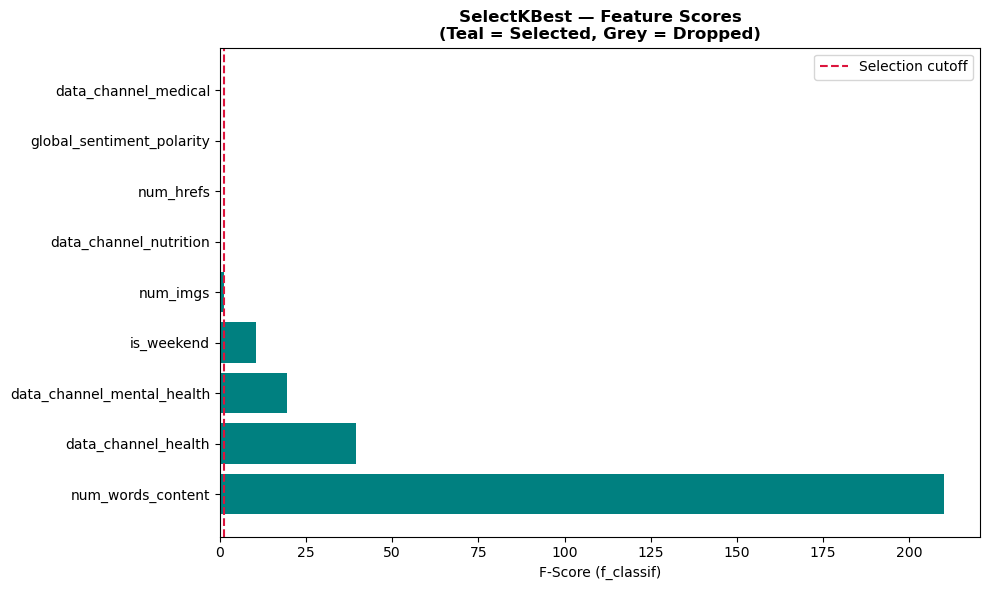

=== SELECTED FEATURES ===
  ✓ num_words_content
  ✓ num_imgs
  ✓ data_channel_health
  ✓ data_channel_mental_health
  ✓ is_weekend

=== AUC COMPARISON ===
Full model AUC    (all features): 0.5824
SelectKBest AUC   (top 5 only):   0.6542
Delta:                            0.0718
SelectKBest AUPRC:                0.3634

=== CLASSIFICATION REPORT (t=0.3232) ===
              precision    recall  f1-score   support

   Not Viral       0.83      0.47      0.60       454
       Viral       0.30      0.71      0.42       146

    accuracy                           0.53       600
   macro avg       0.57      0.59      0.51       600
weighted avg       0.70      0.53      0.56       600


=== FEATURE SELECTION TAKEAWAYS ===

1/ AUC delta of 0.0718 represents meaningful degradation from reducing
   9 features down to 5. 
   The dropped features carry genuine signal — consider k=7 or k=8.

2/ Selected features: num_words_content, num_imgs, data_channel_health, data_channel_mental_health, is_weeke

In [29]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score

# 1. Reuse same split and threshold from Q3
X = df.drop(columns=['shares', 'log_shares'], errors='ignore')
y_raw = df['shares']

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw, test_size=0.2, random_state=420
)

viral_threshold = np.percentile(y_train_raw, 75)
y_train = (y_train_raw >= viral_threshold).astype(int)
y_test  = (y_test_raw  >= viral_threshold).astype(int)

# 2. Preprocessor
numeric_features     = ['num_words_content', 'num_hrefs', 'num_imgs', 'global_sentiment_polarity']
categorical_features = ['data_channel']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

# 3. Pipeline with SelectKBest
feature_selection_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k=5)),
    ('classifier', HistGradientBoostingClassifier(
        class_weight='balanced',  # consistent with Q3
        random_state=420
    ))
])

# 4. Fit
feature_selection_pipeline.fit(X_train, y_train)

# 5. Extract feature names and F-scores
preprocessed_features = (feature_selection_pipeline
                         .named_steps['preprocessor']
                         .get_feature_names_out())
selected_mask     = feature_selection_pipeline.named_steps['feature_selection'].get_support()
selected_features = preprocessed_features[selected_mask]
all_scores        = feature_selection_pipeline.named_steps['feature_selection'].scores_

score_df = pd.DataFrame({
    'Feature':  preprocessed_features,
    'F_Score':  all_scores,
    'Selected': selected_mask
}).sort_values('F_Score', ascending=False)

# 6. F-score bar chart — highlight selected vs dropped
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['teal' if s else 'lightgrey' for s in score_df['Selected']]
ax.barh(score_df['Feature'], score_df['F_Score'], color=colors)
ax.axvline(score_df.loc[score_df['Selected'], 'F_Score'].min(),
           color='crimson', linestyle='--', linewidth=1.5,
           label='Selection cutoff')
ax.set_xlabel('F-Score (f_classif)')
ax.set_title('SelectKBest — Feature Scores\n(Teal = Selected, Grey = Dropped)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("=== SELECTED FEATURES ===")
for feat in selected_features:
    print(f"  ✓ {feat.split('__')[-1]}")

# 7. Probabilities using Q3's optimal threshold
y_proba_skb = feature_selection_pipeline.predict_proba(X_test)[:, 1]
y_pred_skb  = (y_proba_skb >= optimal_threshold).astype(int)

# 8. AUC comparison — full model (Q3) vs SelectKBest (Q4)
auc_full = roc_auc_score(y_test, y_proba)      # y_proba from Q3
auc_skb  = roc_auc_score(y_test, y_proba_skb)
auprc_skb = average_precision_score(y_test, y_proba_skb)

print(f"\n=== AUC COMPARISON ===")
print(f"Full model AUC    (all features): {auc_full:.4f}")
print(f"SelectKBest AUC   (top 5 only):   {auc_skb:.4f}")
print(f"Delta:                            {abs(auc_full - auc_skb):.4f}")
print(f"SelectKBest AUPRC:                {auprc_skb:.4f}")

# 9. Classification report at Q3's optimal threshold
print(f"\n=== CLASSIFICATION REPORT (t={optimal_threshold:.4f}) ===")
print(classification_report(y_test, y_pred_skb,
                             target_names=['Not Viral', 'Viral']))

# 10. Commentary — dynamic from computed values
delta = abs(auc_full - auc_skb)
verdict = "negligible loss" if delta < 0.01 else "meaningful degradation"

print(f"""
=== FEATURE SELECTION TAKEAWAYS ===

1/ AUC delta of {delta:.4f} represents {verdict} from reducing
   {len(preprocessed_features)} features down to 5. 
   {"A simpler model with equivalent performance is preferable in production." 
    if delta < 0.01 else 
    "The dropped features carry genuine signal — consider k=7 or k=8."}

2/ Selected features: {', '.join([f.split('__')[-1] for f in selected_features])}
   These are the statistically significant levers the editorial 
   team can act on — feeds directly into Q5 recommendations.

3/ Threshold held constant at t={optimal_threshold:.4f} from Q3 PR curve
   to ensure fair comparison between full and reduced models.
""")

## Q5 — Business Framing for HealthLine Editorial Team

In [33]:
# ── Dynamic values from Q3 and Q4 ─────────────────────────────────────────
top_channel = channel_summary.iloc[0]
top_channel_name    = top_channel['data_channel']
top_channel_median  = top_channel['median_shares']

selected_features_clean = [f.split('__')[-1] for f in selected_features]

print("=" * 60)
print("HEALTHLINE EDITORIAL TEAM — VIRAL CONTENT PLAYBOOK")
print("=" * 60)

print(f"""
📈 THE BASELINE REALITY
───────────────────────
Viral threshold (75th pct, train only): {viral_threshold:,.0f} shares
Model viral recall at t={optimal_threshold:.2f}:   {viral_recall_at_threshold:.2%}
Full model AUC:                         {auc_full:.4f}
SelectKBest (k=5) AUC:                  {auc_skb:.4f}
AUC delta from feature reduction:       {abs(auc_full - auc_skb):.4f}

Note: Digital virality contains inherent random human behaviour.
The model isolates structural levers the editorial team can control.
""")

print("🛠  THE 5-POINT EDITORIAL BLUEPRINT")
print("SelectKBest identified these features as most statistically significant:")
for i, feat in enumerate(selected_features_clean, 1):
    print(f"  {i}. {feat}")

print(f"""
RECOMMENDED ACTIONS
───────────────────
1/ Weekend Publishing (`is_weekend`)
   Action: Schedule high-value features for Saturday/Sunday.
   Why: Lower industry volume on weekends means HealthLine content
        commands a larger share of reader attention.

2/ Double Down on Core Health (`{top_channel_name}`)
   Action: Prioritise general health reporting in resource allocation.
   Why: Highest median engagement in the dataset 
        ({top_channel_median:,.0f} median shares).

3/ Expand Mental Health Coverage (`data_channel_mental_health`)
   Action: Continue empathy-driven mental health content.
   Why: Builds high-sharing reader communities with strong 
        psychological propensity to share validating content.

4/ Enforce Word Count Minimums (`num_words_content`)
   Action: Set structural length floors for published articles.
   Why: Depth signals medical authority to search and social algorithms.

5/ Visual Asset Requirements (`num_imgs`)
   Action: Require minimum 3-4 images or infographics per article.
   Why: Visual anchors increase scroll depth and share likelihood.

BOTTOM LINE
───────────
Catching {viral_recall_at_threshold:.0%} of viral articles before publication at a precision of {precisions[idx]:.0%} gives the editorial team a reliable pre-publication screening signal 
— actionable at the assignment desk level before a word is written.
""")

HEALTHLINE EDITORIAL TEAM — VIRAL CONTENT PLAYBOOK

📈 THE BASELINE REALITY
───────────────────────
Viral threshold (75th pct, train only): 5,237 shares
Model viral recall at t=0.32:   60.27%
Full model AUC:                         0.5824
SelectKBest (k=5) AUC:                  0.6542
AUC delta from feature reduction:       0.0718

Note: Digital virality contains inherent random human behaviour.
The model isolates structural levers the editorial team can control.

🛠  THE 5-POINT EDITORIAL BLUEPRINT
SelectKBest identified these features as most statistically significant:
  1. num_words_content
  2. num_imgs
  3. data_channel_health
  4. data_channel_mental_health
  5. is_weekend

RECOMMENDED ACTIONS
───────────────────
1/ Weekend Publishing (`is_weekend`)
   Action: Schedule high-value features for Saturday/Sunday.
   Why: Lower industry volume on weekends means HealthLine content
        commands a larger share of reader attention.

2/ Double Down on Core Health (`health`)
   Action: Pr